
# 06b - CQR con MAPIE para los modelos supervisados

Este notebook construye intervalos de predicción para los modelos supervisados mediante regresión cuantílica conformalizada (CQR, *Conformalized Quantile Regression*) utilizando la librería MAPIE.

La lógica sigue la partición cronológica definida en el proyecto para los bloques en el que se divide el conjunto de datos:

- `train` (2020--2022): entrenamiento de los modelos cuantílicos.
- `calibration` (2023): conformalización de los intervalos mediante CQR.
- `validation` (2024): evaluación de cobertura, anchura media e *interval score*.
- `test` (2025): permanece sin utilizar.



## Objetivos del notebook

1. Cargar los datasets de modelado por horizonte, así como las variables predictoras
2. Entrenar versiones cuantílicas de la regresión lineal, LightGBM y CatBoost
3. Aplicar CQR mediante la clase de MAPIE `ConformalizedQuantileRegressor`
4. Evaluar los intervalos preliminares y los intervalos calibrados en el conjunto de validación
5. Guardar los modelos, los intervalos, las tablas y las figuras para la comparación posterior
6. Comprobar que no se utilice el conjunto de prueba


In [1]:


import inspect
import json
from pathlib import Path
from typing import Dict, List

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from mapie.regression import ConformalizedQuantileRegressor
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere la librearía MAPIE con la clase ConformalizedQuantileRegressor."
    ) from exc

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.impute import SimpleImputer
from sklearn.linear_model import QuantileRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool



## Configuración general

Se definen las rutas de trabajo, los horizontes de predicción, el nivel de cobertura nominal y el registro de modelos supervisados.


In [ ]:
# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()

MODELING_DATA_DIR = PROJECT_ROOT / "data" / "modeling"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_PREDICTIONS_DIR = PROJECT_ROOT / "reports" / "predictions"
REPORTS_INTERVALS_DIR = PROJECT_ROOT / "reports" / "intervals"
MODELS_DIR = PROJECT_ROOT / "models" / "cqr_mapie"

for path in [REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR, REPORTS_INTERVALS_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

HORIZONS: List[int] = [1, 4, 12, 24]
TRAIN_SPLIT = "train"
CALIBRATION_SPLIT = "calibration"
VALIDATION_SPLIT = "validation"
TEST_SPLIT = "test"

ALPHA = 0.20
CONFIDENCE_LEVEL = 1 - ALPHA
LOWER_QUANTILE = ALPHA / 2
UPPER_QUANTILE = 1 - ALPHA / 2
MEDIAN_QUANTILE = 0.50

RANDOM_STATE = 42
MAX_EXPECTED_FEATURES = 25
LINEAR_QUANTILE_REGULARIZATION = 1e-4
SYMMETRIC_CORRECTION = True

MODEL_REGISTRY: Dict[str, Dict[str, str]] = {
    "linear_regression": {
        "display_name": "Regresión lineal",
        "interval_prefix": "cqr_linear_regression",
        "point_prediction_prefix": "linear_regression",
        "color": "tab:green",
    },
    "lightgbm": {
        "display_name": "LightGBM",
        "interval_prefix": "cqr_lightgbm",
        "point_prediction_prefix": "lightgbm",
        "color": "tab:red",
    },
    "catboost": {
        "display_name": "CatBoost",
        "interval_prefix": "cqr_catboost",
        "point_prediction_prefix": "catboost",
        "color": "tab:purple",
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
EXAMPLE_MODEL = "catboost"
EXAMPLE_HORIZON = 24
EXAMPLE_HOURS = 14 * 24

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Datasets de modelado: {MODELING_DATA_DIR}")
print(f"Intervalos: {REPORTS_INTERVALS_DIR}")
print(f"Modelos CQR MAPIE: {MODELS_DIR}")
print(f"Cobertura nominal: {CONFIDENCE_LEVEL:.0%}")
print(f"Cuantiles preliminares: {LOWER_QUANTILE:.2f}, {UPPER_QUANTILE:.2f} y mediana {MEDIAN_QUANTILE:.2f}")


Raíz del proyecto: c:\trabajo_github
Datasets de modelado: c:\trabajo_github\data\modeling
Intervalos: c:\trabajo_github\reports\intervals
Modelos CQR MAPIE: c:\trabajo_github\models\cqr_mapie
Cobertura nominal: 80%
Cuantiles preliminares: 0.10, 0.90 y mediana 0.50



## Carga de las variables predictoras y de los datasets de modelado

Los datasets de modelado por horizonte proceden del notebook `02_modeling_dataset_features`. Cada uno contiene una columna `split`, que identifica si la fila pertenece al bloque de entrenamiento, calibración, validación o prueba.


In [3]:

# Carga de las variables predictoras

feature_columns_path = MODELING_DATA_DIR / "feature_columns.json"

if not feature_columns_path.exists():
    raise FileNotFoundError(
        f"No se ha encontrado {feature_columns_path}. Ejecuta primero "
        "02_modeling_dataset_features.ipynb."
    )

feature_payload = json.loads(feature_columns_path.read_text(encoding="utf-8"))
feature_columns_by_horizon = feature_payload["feature_columns_by_horizon"]
default_feature_columns = feature_payload["candidate_feature_columns"]

print("Número de variables candidatas:", len(default_feature_columns))
for horizon in HORIZONS:
    n_features = len(feature_columns_by_horizon.get(str(horizon), default_feature_columns))
    print(f"h={horizon:02d} h -> {n_features} variables")

# Carga de datasets por horizonte.
datasets_by_horizon: Dict[int, pd.DataFrame] = {}

for horizon in HORIZONS:
    dataset_path = MODELING_DATA_DIR / f"modeling_h{horizon:02d}.parquet"

    if not dataset_path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {dataset_path}. Debe ejecutarse primero 02_modeling_dataset_features.ipynb."
        )

    df_h = pd.read_parquet(dataset_path).copy()
    df_h["origin_timestamp"] = pd.to_datetime(df_h["origin_timestamp"])
    df_h["target_timestamp"] = pd.to_datetime(df_h["target_timestamp"])
    datasets_by_horizon[horizon] = df_h

    split_counts = df_h["split"].value_counts(dropna=False).to_dict()
    print(f"h={horizon:02d} h -> {len(df_h):,} filas | splits: {split_counts}")


Número de variables candidatas: 21
h=01 h -> 21 variables
h=04 h -> 21 variables
h=12 h -> 20 variables
h=24 h -> 20 variables
h=01 h -> 50,941 filas | splits: {'train': 25516, 'calibration': 8607, 'validation': 8437, 'test': 8381}
h=04 h -> 50,938 filas | splits: {'train': 25513, 'calibration': 8607, 'validation': 8437, 'test': 8381}
h=12 h -> 50,930 filas | splits: {'train': 25505, 'calibration': 8607, 'validation': 8437, 'test': 8381}
h=24 h -> 50,918 filas | splits: {'train': 25493, 'calibration': 8607, 'validation': 8437, 'test': 8381}



## Funciones auxiliares

Estas funciones preparan los bloques cronológicos, calculan las métricas de intervalo y extraen los límites devueltos por MAPIE.


In [4]:

def as_1d_array(values) -> np.ndarray:
    """Convierte una salida de predicción en un vector unidimensional."""
    array = np.asarray(values, dtype=float)
    if array.ndim == 1:
        return array
    if array.ndim == 2 and array.shape[1] == 1:
        return array[:, 0]
    return array.reshape(-1)

def prepare_split(
    df: pd.DataFrame,
    feature_columns: list[str],
    split_name: str,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """Extrae X, y y metadatos para una partición concreta.

    Solo se eliminan filas sin variable objetivo. Los valores ausentes en las
    variables predictoras se mantienen: la regresión lineal los imputa dentro de
    su pipeline y LightGBM/CatBoost los gestionan de forma nativa.
    """
    split_df = df.loc[df["split"] == split_name].copy()
    split_df = split_df.loc[split_df["y"].notna()].copy()
    split_df = split_df.sort_values("target_timestamp").reset_index(drop=True)

    missing_features = [col for col in feature_columns if col not in split_df.columns]
    if missing_features:
        raise ValueError(f"Faltan variables predictoras en el dataset: {missing_features}")

    X = split_df[feature_columns].copy()
    y = split_df["y"].astype(float).copy()

    metadata_columns = ["horizon", "split", "origin_timestamp", "target_timestamp"]
    metadata = split_df[metadata_columns].copy()

    return X, y, metadata

def finite_sample_quantile(scores: pd.Series | np.ndarray, alpha: float) -> tuple[float, float]:
    """Calcula el cuantíl conforme, para conservar el valor a modo de diagnóstico.
    """
    clean_scores = np.asarray(scores, dtype=float)
    clean_scores = clean_scores[~np.isnan(clean_scores)]

    n_scores = len(clean_scores)
    quantile_level = np.ceil((n_scores + 1) * (1 - alpha)) / n_scores
    quantile_level = min(float(quantile_level), 1.0)

    try:
        q_hat = float(np.quantile(clean_scores, quantile_level, method="higher"))
    except TypeError:
        q_hat = float(np.quantile(clean_scores, quantile_level, interpolation="higher"))

    return q_hat, quantile_level

def interval_score(
    y_true: pd.Series | np.ndarray,
    lower: pd.Series | np.ndarray,
    upper: pd.Series | np.ndarray,
    alpha: float,
) -> np.ndarray:
    """Calcula el interval score para los intervalos centrales."""
    y = np.asarray(y_true, dtype=float)
    l = np.asarray(lower, dtype=float)
    u = np.asarray(upper, dtype=float)

    width = u - l
    lower_penalty = (2 / alpha) * (l - y) * (y < l)
    upper_penalty = (2 / alpha) * (y - u) * (y > u)

    return width + lower_penalty + upper_penalty

def enforce_interval_order(lower: np.ndarray, upper: np.ndarray) -> tuple[np.ndarray, np.ndarray, int]:
    """Garantiza que el límite inferior no supere al superior."""
    lower_arr = np.asarray(lower, dtype=float)
    upper_arr = np.asarray(upper, dtype=float)
    crossed = lower_arr > upper_arr
    ordered_lower = np.minimum(lower_arr, upper_arr)
    ordered_upper = np.maximum(lower_arr, upper_arr)
    return ordered_lower, ordered_upper, int(crossed.sum())

def extract_mapie_output(y_pred, y_interval) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extrae la predicción central, el límite inferior y el límite superior de MAPIE.
    """
    y_pred_array = as_1d_array(y_pred)
    interval_array = np.asarray(y_interval, dtype=float)

    if interval_array.ndim == 2 and interval_array.shape[1] == 2:
        lower = interval_array[:, 0]
        upper = interval_array[:, 1]
    elif interval_array.ndim == 3 and interval_array.shape[1] == 2:
        lower = interval_array[:, 0, 0]
        upper = interval_array[:, 1, 0]
    elif interval_array.ndim == 3 and interval_array.shape[2] == 2:
        lower = interval_array[:, 0, 0]
        upper = interval_array[:, 0, 1]
    else:
        squeezed = np.squeeze(interval_array)
        if squeezed.ndim == 2 and squeezed.shape[1] == 2:
            lower = squeezed[:, 0]
            upper = squeezed[:, 1]

    lower, upper, _ = enforce_interval_order(lower, upper)
    return y_pred_array, lower, upper

def compute_interval_metrics(
    intervals: pd.DataFrame,
    lower_col: str,
    upper_col: str,
    variant: str,
) -> pd.DataFrame:
    """Calcula métricas de intervalo según el modelo y horizonte."""
    rows = []

    for (model_id, horizon), group in intervals.groupby(["model", "horizon"], sort=True):
        valid = group.loc[group["y_true"].notna() & group[lower_col].notna() & group[upper_col].notna()].copy()
        covered = (valid["y_true"] >= valid[lower_col]) & (valid["y_true"] <= valid[upper_col])
        miss_lower = valid["y_true"] < valid[lower_col]
        miss_upper = valid["y_true"] > valid[upper_col]
        widths = valid[upper_col] - valid[lower_col]
        scores = interval_score(valid["y_true"], valid[lower_col], valid[upper_col], ALPHA)

        rows.append(
            {
                "model": model_id,
                "model_display": MODEL_REGISTRY[model_id]["display_name"],
                "method": "cqr_mapie",
                "variant": variant,
                "horizon": int(horizon),
                "alpha": ALPHA,
                "nominal_coverage": CONFIDENCE_LEVEL,
                "n_validation": int(len(valid)),
                "empirical_coverage": float(covered.mean()),
                "coverage_error": float(covered.mean() - CONFIDENCE_LEVEL),
                "mean_width": float(widths.mean()),
                "median_width": float(widths.median()),
                "mean_interval_score": float(np.mean(scores)),
                "median_interval_score": float(np.median(scores)),
                "miss_lower_pct": float(miss_lower.mean() * 100),
                "miss_upper_pct": float(miss_upper.mean() * 100),
                "mean_q_hat": float(valid["q_hat"].mean()) if "q_hat" in valid.columns else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values(["variant", "horizon", "model"]).reset_index(drop=True)



## Envoltorio específico para MAPIE

Aunque MAPIE convierte internamente los `DataFrame` en matrices NumPy, si un estimador se ajusta con nombres de variables (como, por ejemplo, se efectúa en el `Pipeline` de la regresión lineal), scikit-learn emite advertencias al recibir una matriz sin nombres. Para evitarlo, este envoltorio reconstruye el `DataFrame` con los nombres originales, antes de llamar a los modelos internos.


In [5]:

class OrderedQuantileEstimator(BaseEstimator, RegressorMixin):
    """Clase auxiliar que entrega a MAPIE cuantiles ordenados.
    """

    def __init__(
        self,
        role: str,
        lower_model=None,
        upper_model=None,
        median_model=None,
        multiquantile_model=None,
        lower_col: int = 0,
        upper_col: int = 1,
        median_col: int = 2,
        n_features: int | None = None,
        feature_names: tuple[str, ...] | None = None,
    ):
        self.role = role
        self.lower_model = lower_model
        self.upper_model = upper_model
        self.median_model = median_model
        self.multiquantile_model = multiquantile_model
        self.lower_col = lower_col
        self.upper_col = upper_col
        self.median_col = median_col
        self.n_features = n_features
        self.feature_names = feature_names

        # Atributos con guion bajo para que scikit-learn/MAPIE lo considere ajustado.
        self.is_fitted_ = True
        if n_features is not None:
            self.n_features_in_ = int(n_features)
        if feature_names is not None:
            self.feature_names_in_ = np.asarray(feature_names, dtype=object)

    def fit(self, X, y=None):
        self.is_fitted_ = True

        if self.n_features is None:
            self.n_features_in_ = X.shape[1]

        if self.feature_names is None and isinstance(X, pd.DataFrame):
            self.feature_names = tuple(X.columns)
            self.feature_names_in_ = np.asarray(self.feature_names, dtype=object)

        return self

    def _prepare_X(self, X):
        if self.feature_names is None:
            return X

        feature_names = list(self.feature_names)

        if isinstance(X, pd.DataFrame):
            if set(feature_names).issubset(set(X.columns)):
                return X.loc[:, feature_names]
            # Si MAPIE ha creado un DataFrame con columnas numéricas, se reconstruye.
            if X.shape[1] == len(feature_names):
                return pd.DataFrame(X.to_numpy(), columns=feature_names, index=X.index)

        X_array = np.asarray(X)
        return pd.DataFrame(X_array, columns=feature_names)

    def _predict_triplet(self, X) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Obtiene las predicciones del cuantil inferior, del superior y del central."""
        X_prepared = self._prepare_X(X)

        if self.multiquantile_model is not None:
            preds = np.asarray(self.multiquantile_model.predict(X_prepared), dtype=float)
            lower = preds[:, self.lower_col]
            upper = preds[:, self.upper_col]
            median = preds[:, self.median_col]
        else:
            lower = as_1d_array(self.lower_model.predict(X_prepared))
            upper = as_1d_array(self.upper_model.predict(X_prepared))
            median = as_1d_array(self.median_model.predict(X_prepared))

        ordered_lower = np.minimum(lower, upper)
        ordered_upper = np.maximum(lower, upper)

        ordered_median = np.clip(median, ordered_lower, ordered_upper)

        return ordered_lower, ordered_upper, ordered_median

    def predict(self, X):
        lower, upper, median = self._predict_triplet(X)

        if self.role == "lower":
            return lower
        if self.role == "upper":
            return upper
        if self.role == "median":
            return median

        raise ValueError(f"Rol no reconocido: {self.role}")

def make_ordered_wrappers(
    lower_model,
    upper_model,
    median_model,
    n_features: int,
    feature_names: tuple[str, ...],
) -> list[OrderedQuantileEstimator]:
    """Crea los tres estimadores ordenados que espera MAPIE."""
    return [
        OrderedQuantileEstimator(
            "lower",
            lower_model=lower_model,
            upper_model=upper_model,
            median_model=median_model,
            n_features=n_features,
            feature_names=feature_names,
        ),
        OrderedQuantileEstimator(
            "upper",
            lower_model=lower_model,
            upper_model=upper_model,
            median_model=median_model,
            n_features=n_features,
            feature_names=feature_names,
        ),
        OrderedQuantileEstimator(
            "median",
            lower_model=lower_model,
            upper_model=upper_model,
            median_model=median_model,
            n_features=n_features,
            feature_names=feature_names,
        ),
    ]

def make_catboost_multiquantile_wrappers(
    multiquantile_model,
    n_features: int,
    feature_names: tuple[str, ...],
) -> list[OrderedQuantileEstimator]:
    """Crea los tres estimadores ordenados a partir de la función MultiQuantile de CatBoost."""
    return [
        OrderedQuantileEstimator(
            "lower",
            multiquantile_model=multiquantile_model,
            n_features=n_features,
            feature_names=feature_names,
        ),
        OrderedQuantileEstimator(
            "upper",
            multiquantile_model=multiquantile_model,
            n_features=n_features,
            feature_names=feature_names,
        ),
        OrderedQuantileEstimator(
            "median",
            multiquantile_model=multiquantile_model,
            n_features=n_features,
            feature_names=feature_names,
        ),
    ]



## Definición de los modelos cuantílicos

La regresión lineal y LightGBM se entrenan con tres modelos cuantílicos independientes, pero CatBoost utiliza un único modelo `MultiQuantile` para estimar simultáneamente el cuantil inferior, el superior y la mediana.


In [ ]:

# Constructores de los modelos cuantílicos

def build_linear_quantile_regressor(quantile: float) -> Pipeline:
    """Construye una regresión cuantílica lineal."""
    qr_kwargs = {
        "quantile": quantile,
        "alpha": LINEAR_QUANTILE_REGULARIZATION,
    }

    if "solver" in inspect.signature(QuantileRegressor).parameters:
        qr_kwargs["solver"] = "highs"

    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", QuantileRegressor(**qr_kwargs)),
        ]
    )

def read_best_params(model_id: str, horizon: int) -> dict:
    """Lee la configuración seleccionada previamente para LightGBM o CatBoost."""
    if model_id == "lightgbm":
        path = REPORTS_TABLES_DIR / "lightgbm_best_params.csv"
        iteration_column = "selected_n_estimators"
    elif model_id == "catboost":
        path = REPORTS_TABLES_DIR / "catboost_best_params.csv"
        iteration_column = "selected_n_iterations"
    else:
        raise ValueError(f"No hay tabla de hiperparámetros para {model_id}.")

    if not path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {path}. Ejecuta primero el notebook puntual correspondiente."
        )

    params_df = pd.read_csv(path)
    row = params_df.loc[params_df["horizon"] == horizon]
    if row.empty:
        raise ValueError(f"No hay hiperparámetros seleccionados para {model_id}, h={horizon}.")

    row = row.iloc[0]
    params = json.loads(row["params_json"])
    params.pop("config_id", None)
    params["selected_iterations"] = int(row[iteration_column])
    params["selected_config_id"] = row.get("selected_config_id", "unknown")
    return params

def build_lightgbm_quantile_regressor(horizon: int, quantile: float) -> LGBMRegressor:
    """Construye un LightGBM cuantílico reutilizando los hiperparámetros puntuales."""
    params = read_best_params("lightgbm", horizon)
    n_estimators = params.pop("selected_iterations")
    params.pop("selected_config_id", None)

    return LGBMRegressor(
        **params,
        objective="quantile",
        alpha=quantile,
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
        force_col_wise=True,
    )

def build_catboost_multiquantile_regressor(horizon: int) -> CatBoostRegressor:
    """Construye un CatBoost MultiQuantile reutilizando los hiperparámetros puntuales."""
    params = read_best_params("catboost", horizon)
    iterations = params.pop("selected_iterations")
    params.pop("selected_config_id", None)

    alpha_values = f"{LOWER_QUANTILE},{UPPER_QUANTILE},{MEDIAN_QUANTILE}"

    return CatBoostRegressor(
        **params,
        iterations=iterations,
        loss_function=f"MultiQuantile:alpha={alpha_values}",
        random_seed=RANDOM_STATE,
        allow_writing_files=False,
        verbose=False,
    )

def fit_model(model, model_id: str, X: pd.DataFrame, y: pd.Series):
    """Ajusta el modelo."""
    if model_id == "catboost":
        model.fit(Pool(X, label=y), verbose=False)
    else:
        model.fit(X, y)
    return model

def train_prefit_estimators_for_mapie(
    model_id: str,
    horizon: int,
    X_train: pd.DataFrame,
    y_train: pd.Series,
) -> tuple[list[OrderedQuantileEstimator], dict, dict]:
    """Entrena modelos cuantílicos y devuelve los estimadores esperados por MAPIE.
    """
    n_features = X_train.shape[1]
    feature_names = tuple(X_train.columns)

    if model_id == "linear_regression":
        lower_model = build_linear_quantile_regressor(LOWER_QUANTILE)
        upper_model = build_linear_quantile_regressor(UPPER_QUANTILE)
        median_model = build_linear_quantile_regressor(MEDIAN_QUANTILE)

        lower_model = fit_model(lower_model, model_id, X_train, y_train)
        upper_model = fit_model(upper_model, model_id, X_train, y_train)
        median_model = fit_model(median_model, model_id, X_train, y_train)

        estimators = make_ordered_wrappers(
            lower_model,
            upper_model,
            median_model,
            n_features=n_features,
            feature_names=feature_names,
        )
        raw_models = {
            "lower": lower_model,
            "upper": upper_model,
            "median": median_model,
        }
        summary = {
            "quantile_strategy": "three_independent_quantile_models",
            "selected_config_id": "linear_quantile_regression",
            "n_estimators_or_iterations": np.nan,
        }

    elif model_id == "lightgbm":
        lower_model = build_lightgbm_quantile_regressor(horizon, LOWER_QUANTILE)
        upper_model = build_lightgbm_quantile_regressor(horizon, UPPER_QUANTILE)
        median_model = build_lightgbm_quantile_regressor(horizon, MEDIAN_QUANTILE)

        lower_model = fit_model(lower_model, model_id, X_train, y_train)
        upper_model = fit_model(upper_model, model_id, X_train, y_train)
        median_model = fit_model(median_model, model_id, X_train, y_train)

        estimators = make_ordered_wrappers(
            lower_model,
            upper_model,
            median_model,
            n_features=n_features,
            feature_names=feature_names,
        )
        raw_models = {
            "lower": lower_model,
            "upper": upper_model,
            "median": median_model,
        }
        params = read_best_params("lightgbm", horizon)
        summary = {
            "quantile_strategy": "three_independent_quantile_models",
            "selected_config_id": params.get("selected_config_id", "unknown"),
            "n_estimators_or_iterations": params.get("selected_iterations", np.nan),
        }

    elif model_id == "catboost":
        multi_model = build_catboost_multiquantile_regressor(horizon)
        multi_model = fit_model(multi_model, model_id, X_train, y_train)

        estimators = make_catboost_multiquantile_wrappers(
            multi_model,
            n_features=n_features,
            feature_names=feature_names,
        )
        raw_models = {"multiquantile": multi_model}
        params = read_best_params("catboost", horizon)
        summary = {
            "quantile_strategy": "catboost_multiquantile",
            "selected_config_id": params.get("selected_config_id", "unknown"),
            "n_estimators_or_iterations": params.get("selected_iterations", np.nan),
        }

    else:
        raise ValueError(f"Modelo no reconocido: {model_id}")

    summary.update(
        {
            "model": model_id,
            "model_display": MODEL_REGISTRY[model_id]["display_name"],
            "horizon": horizon,
            "n_train": int(len(X_train)),
            "n_features": int(n_features),
        }
    )

    return estimators, raw_models, summary



## Carga de las predicciones puntuales

Las predicciones puntuales se incorporan a las tablas de intervalos para facilitar las comparaciones que se efectuarán posteriormente, pero no se utilizan para la conformalización CQR.


In [ ]:

# Carga de las predicciones puntuales para el conjunto de validación

REQUIRED_POINT_COLUMNS = {"horizon", "split", "origin_timestamp", "target_timestamp", "y_true", "y_pred"}


def load_point_predictions(model_id: str, horizon: int) -> pd.DataFrame:
    """Carga predicciones puntuales previas de un modelo y horizonte."""
    prefix = MODEL_REGISTRY[model_id]["point_prediction_prefix"]
    path = REPORTS_PREDICTIONS_DIR / f"{prefix}_h{horizon:02d}.parquet"

    if not path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {path}. Ejecuta primero el notebook puntual de {model_id}."
        )

    pred = pd.read_parquet(path).copy()
    missing_columns = REQUIRED_POINT_COLUMNS.difference(pred.columns)
    if missing_columns:
        raise ValueError(f"El archivo {path} no contiene las columnas requeridas: {sorted(missing_columns)}")

    pred["origin_timestamp"] = pd.to_datetime(pred["origin_timestamp"])
    pred["target_timestamp"] = pd.to_datetime(pred["target_timestamp"])
    pred = pred.loc[pred["split"] == VALIDATION_SPLIT].copy()
    pred = pred.loc[pred["y_true"].notna() & pred["y_pred"].notna()].copy()

    return pred[["horizon", "split", "origin_timestamp", "target_timestamp", "y_true", "y_pred"]]

point_availability_rows = []
for model_id in MODEL_ORDER:
    for horizon in HORIZONS:
        pred = load_point_predictions(model_id, horizon)
        point_availability_rows.append(
            {
                "model": model_id,
                "model_display": MODEL_REGISTRY[model_id]["display_name"],
                "horizon": horizon,
                "n_point_predictions_validation": len(pred),
                "target_start": pred["target_timestamp"].min(),
                "target_end": pred["target_timestamp"].max(),
            }
        )

point_availability_df = pd.DataFrame(point_availability_rows)
display(point_availability_df)


,model,model_display,horizon,n_point_predictions_validation,target_start,target_end
0,linear_regression,Regresión lineal,1,8437,2024-01-01,2024-12-31 23:00:00
1,linear_regression,Regresión lineal,4,8437,2024-01-01,2024-12-31 23:00:00
2,linear_regression,Regresión lineal,12,8437,2024-01-01,2024-12-31 23:00:00
3,linear_regression,Regresión lineal,24,8437,2024-01-01,2024-12-31 23:00:00
4,lightgbm,LightGBM,1,8437,2024-01-01,2024-12-31 23:00:00
5,lightgbm,LightGBM,4,8437,2024-01-01,2024-12-31 23:00:00
6,lightgbm,LightGBM,12,8437,2024-01-01,2024-12-31 23:00:00
7,lightgbm,LightGBM,24,8437,2024-01-01,2024-12-31 23:00:00
8,catboost,CatBoost,1,8437,2024-01-01,2024-12-31 23:00:00
9,catboost,CatBoost,4,8437,2024-01-01,2024-12-31 23:00:00



## Entrenamiento cuantílico y conformalización con MAPIE

A continuación, se entrenarán los cuantiles necesarios para cada modelo y se construirán los intervalos de predicción.

In [8]:

# Entrenamiento, conformalización y construcción de intervalos

interval_frames: list[pd.DataFrame] = []
metrics_rows: list[dict] = []
calibration_summary_rows: list[dict] = []
training_summary_rows: list[dict] = []
quantile_model_summary_rows: list[dict] = []
model_save_rows: list[dict] = []

predict_interval_signature = inspect.signature(ConformalizedQuantileRegressor.predict_interval)
PREDICT_INTERVAL_KWARGS = {}
if "symmetric_correction" in predict_interval_signature.parameters:
    PREDICT_INTERVAL_KWARGS["symmetric_correction"] = SYMMETRIC_CORRECTION

for model_id in MODEL_ORDER:
    print("=" * 100)
    print(f"Modelo: {MODEL_REGISTRY[model_id]['display_name']}")

    for horizon in HORIZONS:
        print("-" * 100)
        print(f"CQR con MAPIE - {MODEL_REGISTRY[model_id]['display_name']} - h={horizon} h")

        df = datasets_by_horizon[horizon]
        feature_columns = feature_columns_by_horizon.get(str(horizon), default_feature_columns)

        if len(feature_columns) > MAX_EXPECTED_FEATURES:
            raise AssertionError(
                f"El horizonte {horizon} supera el número máximo de variables previsto."
            )

        X_train, y_train, train_metadata = prepare_split(df, feature_columns, TRAIN_SPLIT)
        X_cal, y_cal, calibration_metadata = prepare_split(df, feature_columns, CALIBRATION_SPLIT)
        X_val, y_val, validation_metadata = prepare_split(df, feature_columns, VALIDATION_SPLIT)

        if X_train.empty or X_cal.empty or X_val.empty:
            raise ValueError(
                f"Partición vacía para {model_id}, h={horizon}: "
                f"train={len(X_train)}, calibration={len(X_cal)}, validation={len(X_val)}"
            )

        estimators_for_mapie, raw_models, train_summary = train_prefit_estimators_for_mapie(
            model_id=model_id,
            horizon=horizon,
            X_train=X_train,
            y_train=y_train,
        )
        lower_estimator, upper_estimator, median_estimator = estimators_for_mapie

        # Intervalos preliminares (no conformalizados).
        cal_lower_raw = lower_estimator.predict(X_cal)
        cal_upper_raw = upper_estimator.predict(X_cal)
        val_lower_raw = lower_estimator.predict(X_val)
        val_upper_raw = upper_estimator.predict(X_val)
        val_median_raw = median_estimator.predict(X_val)

        cal_lower, cal_upper, n_cal_crossed = enforce_interval_order(cal_lower_raw, cal_upper_raw)
        val_lower, val_upper, n_val_crossed = enforce_interval_order(val_lower_raw, val_upper_raw)

        calibration_scores = np.maximum(cal_lower - y_cal.to_numpy(), y_cal.to_numpy() - cal_upper)
        q_hat, q_level = finite_sample_quantile(calibration_scores, ALPHA)

        mapie_cqr = ConformalizedQuantileRegressor(
            estimator=estimators_for_mapie,
            confidence_level=CONFIDENCE_LEVEL,
            prefit=True,
        )
        mapie_cqr.conformalize(X_cal, y_cal)
        y_pred_mapie, intervals_mapie = mapie_cqr.predict_interval(X_val, **PREDICT_INTERVAL_KWARGS)
        y_pred_mapie, lower_cqr, upper_cqr = extract_mapie_output(y_pred_mapie, intervals_mapie)
        lower_cqr, upper_cqr, n_final_crossed = enforce_interval_order(lower_cqr, upper_cqr)

        point_predictions = load_point_predictions(model_id, horizon).rename(columns={"y_pred": "y_pred_point"})

        validation_intervals = validation_metadata.copy()
        validation_intervals["model"] = model_id
        validation_intervals["model_display"] = MODEL_REGISTRY[model_id]["display_name"]
        validation_intervals["method"] = "cqr_mapie"
        validation_intervals["alpha"] = ALPHA
        validation_intervals["nominal_coverage"] = CONFIDENCE_LEVEL
        validation_intervals["lower_quantile"] = LOWER_QUANTILE
        validation_intervals["upper_quantile"] = UPPER_QUANTILE
        validation_intervals["q_hat"] = q_hat
        validation_intervals["q_level"] = q_level
        validation_intervals["y_true"] = y_val.to_numpy()
        validation_intervals["y_pred_quantile_median"] = val_median_raw
        validation_intervals["y_pred_mapie"] = y_pred_mapie
        validation_intervals["lower_prelim"] = val_lower
        validation_intervals["upper_prelim"] = val_upper
        validation_intervals["lower"] = lower_cqr
        validation_intervals["upper"] = upper_cqr
        validation_intervals["raw_interval_width"] = validation_intervals["upper_prelim"] - validation_intervals["lower_prelim"]
        validation_intervals["interval_width"] = validation_intervals["upper"] - validation_intervals["lower"]
        validation_intervals["covered"] = (
            (validation_intervals["y_true"] >= validation_intervals["lower"])
            & (validation_intervals["y_true"] <= validation_intervals["upper"])
        )
        validation_intervals["miss_lower"] = validation_intervals["y_true"] < validation_intervals["lower"]
        validation_intervals["miss_upper"] = validation_intervals["y_true"] > validation_intervals["upper"]

        validation_intervals = validation_intervals.merge(
            point_predictions[["origin_timestamp", "target_timestamp", "y_pred_point"]],
            on=["origin_timestamp", "target_timestamp"],
            how="left",
        )

        interval_frames.append(validation_intervals)

        training_summary_rows.append(train_summary)
        calibration_summary_rows.append(
            {
                "model": model_id,
                "model_display": MODEL_REGISTRY[model_id]["display_name"],
                "horizon": horizon,
                "method": "cqr_mapie",
                "alpha": ALPHA,
                "nominal_coverage": CONFIDENCE_LEVEL,
                "n_calibration": int(len(X_cal)),
                "q_hat": q_hat,
                "q_level": q_level,
                "mean_score": float(np.mean(calibration_scores)),
                "median_score": float(np.median(calibration_scores)),
                "n_crossed_calibration_prelim": n_cal_crossed,
                "n_crossed_validation_prelim": n_val_crossed,
                "n_crossed_validation_final": n_final_crossed,
            }
        )

        # Guardado de los modelos cuantílicos y del objeto MAPIE.
        model_prefix = f"cqr_mapie_{model_id}_h{horizon:02d}"
        mapie_path = MODELS_DIR / f"{model_prefix}_mapie.joblib"
        joblib.dump(mapie_cqr, mapie_path)
        model_save_rows.append({"model": model_id, "horizon": horizon, "role": "mapie", "path": str(mapie_path)})

        for role, model in raw_models.items():
            model_path = MODELS_DIR / f"{model_prefix}_{role}.joblib"
            joblib.dump(model, model_path)
            model_save_rows.append({"model": model_id, "horizon": horizon, "role": role, "path": str(model_path)})

            quantile_model_summary_rows.append(
                {
                    "model": model_id,
                    "model_display": MODEL_REGISTRY[model_id]["display_name"],
                    "horizon": horizon,
                    "role": role,
                    "model_path": str(model_path),
                }
            )

cqr_intervals = pd.concat(interval_frames, ignore_index=True)
training_summary_df = pd.DataFrame(training_summary_rows).sort_values(["horizon", "model"]).reset_index(drop=True)
calibration_summary_df = pd.DataFrame(calibration_summary_rows).sort_values(["horizon", "model"]).reset_index(drop=True)
quantile_model_summary_df = pd.DataFrame(quantile_model_summary_rows).sort_values(["horizon", "model", "role"]).reset_index(drop=True)
model_save_df = pd.DataFrame(model_save_rows).sort_values(["horizon", "model", "role"]).reset_index(drop=True)

print("Intervalos CQR generados:", len(cqr_intervals))
display(training_summary_df)
display(calibration_summary_df)


Modelo: Regresión lineal
----------------------------------------------------------------------------------------------------
CQR con MAPIE · Regresión lineal · h=1 h
----------------------------------------------------------------------------------------------------
CQR con MAPIE · Regresión lineal · h=4 h
----------------------------------------------------------------------------------------------------
CQR con MAPIE · Regresión lineal · h=12 h
----------------------------------------------------------------------------------------------------
CQR con MAPIE · Regresión lineal · h=24 h
Modelo: LightGBM
----------------------------------------------------------------------------------------------------
CQR con MAPIE · LightGBM · h=1 h
----------------------------------------------------------------------------------------------------
CQR con MAPIE · LightGBM · h=4 h
----------------------------------------------------------------------------------------------------
CQR con MAPIE · Lig

,quantile_strategy,selected_config_id,n_estimators_or_iterations,model,model_display,horizon,n_train,n_features
0,catboost_multiquantile,base,345.000,catboost,CatBoost,1,25516,21
1,three_independent_quantile_models,small_leaves,404.000,lightgbm,LightGBM,1,25516,21
2,three_independent_quantile_models,linear_quantile_regression,NaN,linear_regression,Regresión lineal,1,25516,21
3,catboost_multiquantile,base,276.000,catboost,CatBoost,4,25513,21
4,three_independent_quantile_models,small_leaves,311.000,lightgbm,LightGBM,4,25513,21
5,three_independent_quantile_models,linear_quantile_regression,NaN,linear_regression,Regresión lineal,4,25513,21
6,catboost_multiquantile,regularized,475.000,catboost,CatBoost,12,25505,20
7,three_independent_quantile_models,regularized,113.000,lightgbm,LightGBM,12,25505,20
8,three_independent_quantile_models,linear_quantile_regression,NaN,linear_regression,Regresión lineal,12,25505,20
9,catboost_multiquantile,base,105.000,catboost,CatBoost,24,25493,20


,model,model_display,horizon,method,alpha,nominal_coverage,n_calibration,q_hat,q_level,mean_score,median_score,n_crossed_calibration_prelim,n_crossed_validation_prelim,n_crossed_validation_final
0,catboost,CatBoost,1,cqr_mapie,0.200,0.800,8607,0.595,0.800,-2.842,-3.530,0,0,0
1,lightgbm,LightGBM,1,cqr_mapie,0.200,0.800,8607,0.429,0.800,-2.931,-3.523,0,0,0
2,linear_regression,Regresión lineal,1,cqr_mapie,0.200,0.800,8607,0.325,0.800,-3.543,-4.746,0,0,0
3,catboost,CatBoost,4,cqr_mapie,0.200,0.800,8607,1.397,0.800,-4.894,-5.953,0,0,0
4,lightgbm,LightGBM,4,cqr_mapie,0.200,0.800,8607,1.081,0.800,-5.344,-6.202,0,0,0
5,linear_regression,Regresión lineal,4,cqr_mapie,0.200,0.800,8607,0.225,0.800,-7.290,-8.786,0,0,0
6,catboost,CatBoost,12,cqr_mapie,0.200,0.800,8607,2.286,0.800,-5.154,-6.147,0,0,0
7,lightgbm,LightGBM,12,cqr_mapie,0.200,0.800,8607,1.533,0.800,-5.906,-6.850,0,0,0
8,linear_regression,Regresión lineal,12,cqr_mapie,0.200,0.800,8607,0.014,0.800,-8.103,-9.604,0,0,0
9,catboost,CatBoost,24,cqr_mapie,0.200,0.800,8607,0.639,0.800,-6.750,-7.866,0,0,0



## Métricas de los intervalos

Se evalúan tanto los intervalos cuantílicos preliminares como los intervalos calibrados mediante CQR. La comparación principal posterior utilizará, lógicamente, los intervalos calibrados.


In [9]:

# Evaluación de los intervalos preliminares y calibrados

prelim_metrics_df = compute_interval_metrics(
    intervals=cqr_intervals,
    lower_col="lower_prelim",
    upper_col="upper_prelim",
    variant="preliminary_quantile_interval",
)

calibrated_metrics_df = compute_interval_metrics(
    intervals=cqr_intervals,
    lower_col="lower",
    upper_col="upper",
    variant="cqr_calibrated_interval",
)

cqr_metrics_df = pd.concat([prelim_metrics_df, calibrated_metrics_df], ignore_index=True)

print("Métricas de intervalos preliminares:")
display(prelim_metrics_df.round(3))

print("Métricas de intervalos CQR calibrados:")
display(calibrated_metrics_df.round(3))


Métricas de intervalos preliminares:


,model,model_display,method,variant,horizon,alpha,nominal_coverage,n_validation,empirical_coverage,coverage_error,mean_width,median_width,mean_interval_score,median_interval_score,miss_lower_pct,miss_upper_pct,mean_q_hat
0,catboost,CatBoost,cqr_mapie,preliminary_quantile_interval,1,0.200,0.800,8437,0.771,-0.029,18.545,18.183,29.688,19.959,10.407,12.481,0.595
1,lightgbm,LightGBM,cqr_mapie,preliminary_quantile_interval,1,0.200,0.800,8437,0.774,-0.026,18.826,18.011,29.866,19.809,10.027,12.564,0.429
2,linear_regression,Regresión lineal,cqr_mapie,preliminary_quantile_interval,1,0.200,0.800,8437,0.793,-0.007,20.903,20.500,32.391,21.623,9.518,11.141,0.325
3,catboost,CatBoost,cqr_mapie,preliminary_quantile_interval,4,0.200,0.800,8437,0.739,-0.061,33.051,32.325,50.161,35.687,11.165,14.887,1.397
4,lightgbm,LightGBM,cqr_mapie,preliminary_quantile_interval,4,0.200,0.800,8437,0.754,-0.046,34.884,34.225,50.861,37.233,10.098,14.531,1.081
5,linear_regression,Regresión lineal,cqr_mapie,preliminary_quantile_interval,4,0.200,0.800,8437,0.793,-0.007,40.517,40.026,54.970,41.968,9.115,11.568,0.225
6,catboost,CatBoost,cqr_mapie,preliminary_quantile_interval,12,0.200,0.800,8437,0.715,-0.085,37.409,36.430,58.278,40.645,10.987,17.506,2.286
7,lightgbm,LightGBM,cqr_mapie,preliminary_quantile_interval,12,0.200,0.800,8437,0.735,-0.065,39.848,38.841,58.696,42.686,9.778,16.688,1.533
8,linear_regression,Regresión lineal,cqr_mapie,preliminary_quantile_interval,12,0.200,0.800,8437,0.789,-0.011,45.001,44.856,60.402,47.092,7.906,13.168,0.014
9,catboost,CatBoost,cqr_mapie,preliminary_quantile_interval,24,0.200,0.800,8437,0.751,-0.049,41.681,40.480,59.459,43.532,8.712,16.143,0.639


Métricas de intervalos CQR calibrados:


,model,model_display,method,variant,horizon,alpha,nominal_coverage,n_validation,empirical_coverage,coverage_error,mean_width,median_width,mean_interval_score,median_interval_score,miss_lower_pct,miss_upper_pct,mean_q_hat
0,catboost,CatBoost,cqr_mapie,cqr_calibrated_interval,1,0.200,0.800,8437,0.803,0.003,19.732,19.370,29.626,20.853,8.641,11.106,0.595
1,lightgbm,LightGBM,cqr_mapie,cqr_calibrated_interval,1,0.200,0.800,8437,0.801,0.001,19.679,18.865,29.827,20.477,8.451,11.485,0.429
2,linear_regression,Regresión lineal,cqr_mapie,cqr_calibrated_interval,1,0.200,0.800,8437,0.804,0.004,21.550,21.148,32.387,22.180,9.032,10.549,0.325
3,catboost,CatBoost,cqr_mapie,cqr_calibrated_interval,4,0.200,0.800,8437,0.790,-0.010,35.821,35.095,49.702,37.479,8.332,12.670,1.397
4,lightgbm,LightGBM,cqr_mapie,cqr_calibrated_interval,4,0.200,0.800,8437,0.796,-0.004,37.045,36.386,50.627,38.821,7.811,12.587,1.081
5,linear_regression,Regresión lineal,cqr_mapie,cqr_calibrated_interval,4,0.200,0.800,8437,0.798,-0.002,40.958,40.467,54.960,42.317,8.878,11.319,0.225
6,catboost,CatBoost,cqr_mapie,cqr_calibrated_interval,12,0.200,0.800,8437,0.795,-0.005,41.977,40.998,57.325,43.728,7.005,13.488,2.286
7,lightgbm,LightGBM,cqr_mapie,cqr_calibrated_interval,12,0.200,0.800,8437,0.792,-0.008,42.909,41.902,58.212,44.930,6.697,14.057,1.533
8,linear_regression,Regresión lineal,cqr_mapie,cqr_calibrated_interval,12,0.200,0.800,8437,0.789,-0.011,45.022,44.877,60.401,47.108,7.906,13.144,0.014
9,catboost,CatBoost,cqr_mapie,cqr_calibrated_interval,24,0.200,0.800,8437,0.777,-0.023,42.955,41.753,59.236,44.390,7.147,15.112,0.639



## Disponibilidad de los intervalos

Se imprime una tabla con el número de intervalos generados por modelo y horizonte.


In [10]:

# Resumen de disponibilidad de intervalos

interval_availability_rows = []

for (model_id, horizon), group in cqr_intervals.groupby(["model", "horizon"], sort=True):
    interval_availability_rows.append(
        {
            "model": model_id,
            "model_display": MODEL_REGISTRY[model_id]["display_name"],
            "horizon": int(horizon),
            "n_intervals": int(len(group)),
            "target_start": group["target_timestamp"].min(),
            "target_end": group["target_timestamp"].max(),
            "missing_y_pct": float(group["y_true"].isna().mean() * 100),
            "missing_lower_pct": float(group["lower"].isna().mean() * 100),
            "missing_upper_pct": float(group["upper"].isna().mean() * 100),
        }
    )

interval_availability_df = pd.DataFrame(interval_availability_rows).sort_values(["horizon", "model"]).reset_index(drop=True)
display(interval_availability_df)


,model,model_display,horizon,n_intervals,target_start,target_end,missing_y_pct,missing_lower_pct,missing_upper_pct
0,catboost,CatBoost,1,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000,0.000
1,lightgbm,LightGBM,1,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000,0.000
2,linear_regression,Regresión lineal,1,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000,0.000
3,catboost,CatBoost,4,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000,0.000
4,lightgbm,LightGBM,4,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000,0.000
5,linear_regression,Regresión lineal,4,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000,0.000
6,catboost,CatBoost,12,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000,0.000
7,lightgbm,LightGBM,12,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000,0.000
8,linear_regression,Regresión lineal,12,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000,0.000
9,catboost,CatBoost,24,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000,0.000



## Guardado de los intervalos, los modelos y las tablas

Se guardan los intervalos por modelo y horizonte, además de las tablas necesarias para el notebook en el que se compararán los intervalos.


In [11]:

# Guardado de intervalos y tablas

interval_paths = []

for (model_id, horizon), group in cqr_intervals.groupby(["model", "horizon"], sort=True):
    prefix = MODEL_REGISTRY[model_id]["interval_prefix"]
    output_path = REPORTS_INTERVALS_DIR / f"{prefix}_h{horizon:02d}.parquet"
    group.sort_values("target_timestamp").to_parquet(output_path, index=False)
    interval_paths.append(output_path)
    print(f"Intervalos guardados: {output_path}")

metrics_path = REPORTS_TABLES_DIR / "cqr_supervised_interval_metrics.csv"
prelim_metrics_path = REPORTS_TABLES_DIR / "cqr_supervised_preliminary_interval_metrics.csv"
calibrated_metrics_path = REPORTS_TABLES_DIR / "cqr_supervised_calibrated_interval_metrics.csv"
calibration_summary_path = REPORTS_TABLES_DIR / "cqr_supervised_calibration_summary.csv"
training_summary_path = REPORTS_TABLES_DIR / "cqr_supervised_training_summary.csv"
quantile_model_summary_path = REPORTS_TABLES_DIR / "cqr_supervised_quantile_model_summary.csv"
model_save_path = REPORTS_TABLES_DIR / "cqr_supervised_saved_models.csv"
interval_availability_path = REPORTS_TABLES_DIR / "cqr_supervised_interval_availability.csv"
sample_path = REPORTS_TABLES_DIR / "cqr_supervised_intervals_sample.csv"

cqr_metrics_df.to_csv(metrics_path, index=False)
prelim_metrics_df.to_csv(prelim_metrics_path, index=False)
calibrated_metrics_df.to_csv(calibrated_metrics_path, index=False)
calibration_summary_df.to_csv(calibration_summary_path, index=False)
training_summary_df.to_csv(training_summary_path, index=False)
quantile_model_summary_df.to_csv(quantile_model_summary_path, index=False)
model_save_df.to_csv(model_save_path, index=False)
interval_availability_df.to_csv(interval_availability_path, index=False)
cqr_intervals.head(300).to_csv(sample_path, index=False)

for path in [
    metrics_path,
    prelim_metrics_path,
    calibrated_metrics_path,
    calibration_summary_path,
    training_summary_path,
    quantile_model_summary_path,
    model_save_path,
    interval_availability_path,
    sample_path,
]:
    print(f"Tabla guardada: {path}")


Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_catboost_h01.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_catboost_h04.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_catboost_h12.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_catboost_h24.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_lightgbm_h01.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_lightgbm_h04.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_lightgbm_h12.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_lightgbm_h24.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_linear_regression_h01.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_linear_regression_h04.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cqr_linear_regression_h12.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\cq


## Figura 1 - Cuantíl conforme por modelo y horizonte

El valor `q_hat` resume cuánto debe de ensancharse el intervalo cuantílico preliminar para alcanzar la cobertura objetivo tras la conformalización.


Figura guardada en: c:\trabajo_github\reports\figures\fig_cqr_supervised_qhat.png


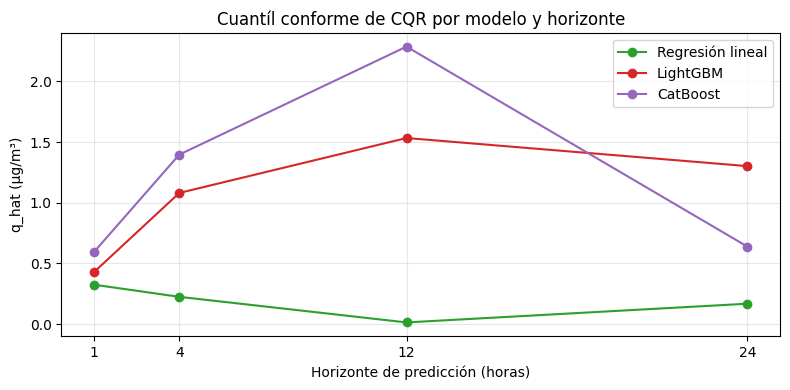

In [ ]:

# Figura del cuantíl conforme por modelo y horizonte

fig, ax = plt.subplots(figsize=(8, 4))

for model_id in MODEL_ORDER:
    model_df = calibration_summary_df.loc[calibration_summary_df["model"] == model_id].sort_values("horizon")
    ax.plot(
        model_df["horizon"],
        model_df["q_hat"],
        marker="o",
        label=MODEL_REGISTRY[model_id]["display_name"],
        color=MODEL_REGISTRY[model_id]["color"],
    )

ax.set_title("Cuantíl conforme de CQR por modelo y horizonte")
ax.set_xlabel("Horizonte de predicción (horas)")
ax.set_ylabel("q_hat (µg/m³)")
ax.set_xticks(HORIZONS)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()

qhat_figure_path = REPORTS_FIGURES_DIR / "fig_cqr_supervised_qhat.png"
fig.savefig(qhat_figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {qhat_figure_path}")
plt.show()



## Figura 2 - Métricas de los intervalos de predicción en el conjunto de validación

Se muestran las métricas principales de los intervalos de predicción: la cobertura empírica, la anchura media y *interval score*.


Figura guardada en: c:\trabajo_github\reports\figures\fig_cqr_supervised_interval_metrics.png


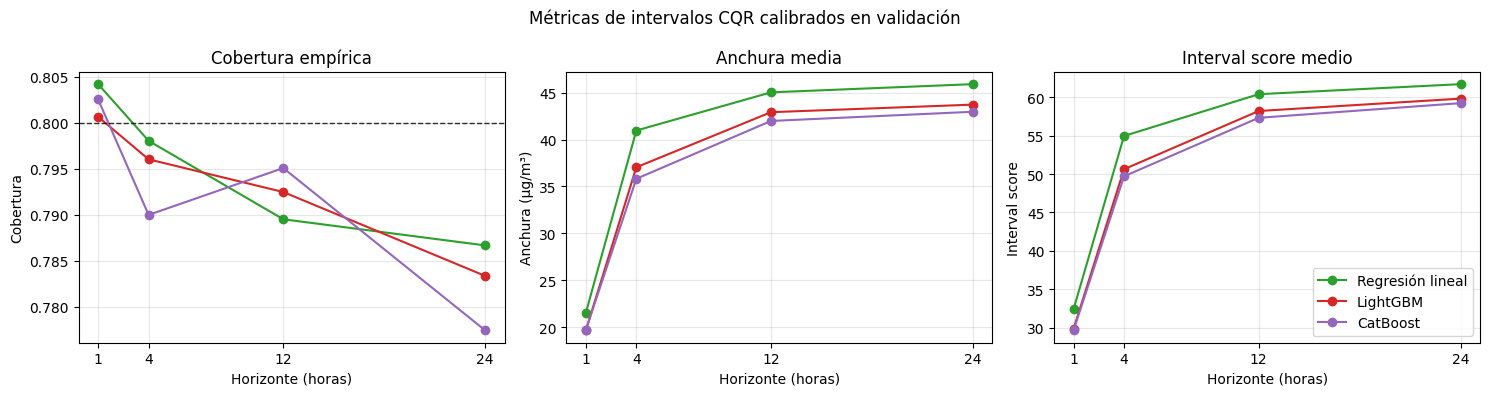

In [ ]:

# Figura de métricas de los intervalos de predicción

plot_metrics_df = calibrated_metrics_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

for model_id in MODEL_ORDER:
    model_df = plot_metrics_df.loc[plot_metrics_df["model"] == model_id].sort_values("horizon")
    label = MODEL_REGISTRY[model_id]["display_name"]
    color = MODEL_REGISTRY[model_id]["color"]

    axes[0].plot(model_df["horizon"], model_df["empirical_coverage"], marker="o", label=label, color=color)
    axes[1].plot(model_df["horizon"], model_df["mean_width"], marker="o", label=label, color=color)
    axes[2].plot(model_df["horizon"], model_df["mean_interval_score"], marker="o", label=label, color=color)

axes[0].axhline(CONFIDENCE_LEVEL, linestyle="--", linewidth=1, color="black", alpha=0.8)
axes[0].set_title("Cobertura empírica")
axes[0].set_ylabel("Cobertura")

axes[1].set_title("Anchura media")
axes[1].set_ylabel("Anchura (µg/m³)")

axes[2].set_title("Interval score medio")
axes[2].set_ylabel("Interval score")
axes[2].legend(loc="best")

for ax in axes:
    ax.set_xlabel("Horizonte (horas)")
    ax.set_xticks(HORIZONS)
    ax.grid(True, alpha=0.3)

fig.suptitle("Métricas de los intervalos de predicción obtenidas en el conjunto de validación")
fig.tight_layout()

metrics_figure_path = REPORTS_FIGURES_DIR / "fig_cqr_supervised_interval_metrics.png"
fig.savefig(metrics_figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {metrics_figure_path}")
plt.show()



## Figura 3 - Cobertura preliminar frente a cobertura calibrada

Esta figura permite comprobar cómo de bien corrige CQR los déficits de cobertura que inicialmente se dan en los intervalos preliminares.


Figura guardada en: c:\trabajo_github\reports\figures\fig_cqr_supervised_raw_vs_calibrated_coverage.png


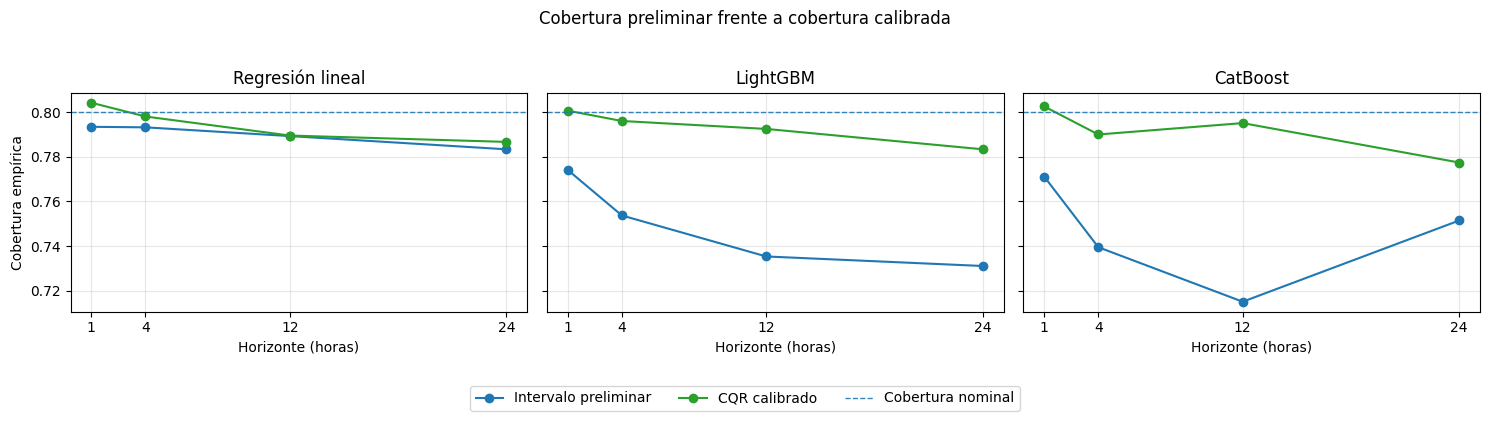

In [ ]:

# Figura que compara la cobertura preliminar y la obtenida mediante CQR

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

legend_handles = None
legend_labels = None

for ax, model_id in zip(axes, MODEL_ORDER):
    prelim_df = prelim_metrics_df.loc[prelim_metrics_df["model"] == model_id].sort_values("horizon")
    calib_df = calibrated_metrics_df.loc[calibrated_metrics_df["model"] == model_id].sort_values("horizon")

    ax.plot(
        prelim_df["horizon"],
        prelim_df["empirical_coverage"],
        marker="o",
        color="tab:blue",
        label="Intervalo preliminar",
    )
    ax.plot(
        calib_df["horizon"],
        calib_df["empirical_coverage"],
        marker="o",
        color="tab:green",
        label="CQR calibrado",
    )
    ax.axhline(
        CONFIDENCE_LEVEL,
        linestyle="--",
        linewidth=1,
        color="tab:blue",
        alpha=0.9,
        label="Cobertura nominal",
    )

    ax.set_title(MODEL_REGISTRY[model_id]["display_name"])
    ax.set_xlabel("Horizonte (horas)")
    ax.set_xticks(HORIZONS)
    ax.grid(True, alpha=0.3)

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

axes[0].set_ylabel("Cobertura empírica")
fig.suptitle("Cobertura preliminar frente a cobertura calibrada")
fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.04),
)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

coverage_figure_path = REPORTS_FIGURES_DIR / "fig_cqr_supervised_raw_vs_calibrated_coverage.png"
fig.savefig(coverage_figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {coverage_figure_path}")
plt.show()



## Inspección visual de los intervalos

Se selecciona un tramo continuo de validación para visualizar las predicciones puntuales y los intervalos de predicción de un modelo y horizonte concretos.


In [ ]:

# Selección de un bloque continuo para la inspección visual

example = cqr_intervals.loc[
    (cqr_intervals["model"] == EXAMPLE_MODEL)
    & (cqr_intervals["horizon"] == EXAMPLE_HORIZON)
].copy()

example = example.sort_values("target_timestamp")
example["delta_h"] = example["target_timestamp"].diff() / pd.Timedelta(hours=1)
example["continuous_block"] = (example["delta_h"].isna() | (example["delta_h"] != 1)).cumsum()

block_summary = (
    example.groupby("continuous_block")
    .agg(
        start=("target_timestamp", "min"),
        end=("target_timestamp", "max"),
        n_hours=("target_timestamp", "count"),
    )
    .reset_index()
)

candidate_blocks = block_summary.loc[block_summary["n_hours"] >= EXAMPLE_HOURS]

if candidate_blocks.empty:
    selected_block_id = block_summary.sort_values(["n_hours", "start"], ascending=[False, True]).iloc[0]["continuous_block"]
    print(f"No existe un bloque continuo de {EXAMPLE_HOURS} horas. Se usará el bloque más largo.")
else:
    selected_block_id = candidate_blocks.sort_values("start").iloc[0]["continuous_block"]

example_zoom = example.loc[example["continuous_block"] == selected_block_id].head(EXAMPLE_HOURS).copy()

print(
    "Tramo seleccionado:",
    example_zoom["target_timestamp"].min(),
    "→",
    example_zoom["target_timestamp"].max(),
    f"({len(example_zoom)} horas)",
)


Tramo seleccionado: 2024-01-16 14:00:00 → 2024-01-30 13:00:00 (336 horas)


Figura guardada en: c:\trabajo_github\reports\figures\fig_cqr_catboost_interval_zoom_h24.png


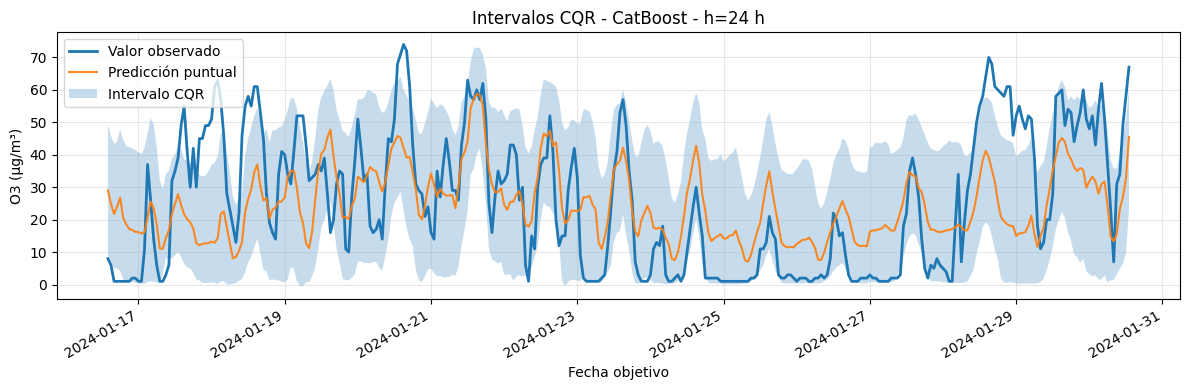

In [ ]:

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    example_zoom["target_timestamp"],
    example_zoom["y_true"],
    label="Valor observado",
    linewidth=2,
)

if example_zoom["y_pred_point"].notna().any():
    ax.plot(
        example_zoom["target_timestamp"],
        example_zoom["y_pred_point"],
        label="Predicción puntual",
        alpha=0.9,
    )
else:
    ax.plot(
        example_zoom["target_timestamp"],
        example_zoom["y_pred_mapie"],
        label="Predicción MAPIE",
        alpha=0.9,
    )

ax.fill_between(
    example_zoom["target_timestamp"],
    example_zoom["lower"],
    example_zoom["upper"],
    alpha=0.25,
    label="Intervalo CQR",
)

ax.set_title(
    f"Intervalos CQR - {MODEL_REGISTRY[EXAMPLE_MODEL]['display_name']} - "
    f"h={EXAMPLE_HORIZON} h"
)
ax.set_xlabel("Fecha objetivo")
ax.set_ylabel("O3 (µg/m³)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.autofmt_xdate()
fig.tight_layout()

example_figure_path = REPORTS_FIGURES_DIR / f"fig_cqr_{EXAMPLE_MODEL}_interval_zoom_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(example_figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {example_figure_path}")
plt.show()



## Comprobaciones finales

Comprobaciones que verifican que no se haya usado el conjunto de prueba, que existan intervalos para todos los modelos y horizontes, y que no haya intervalos con el cuartil inferior por encima del superior.


In [17]:

# Comprobaciones finales
# ==============================================================================
checks = {
    "intervalos_guardados": all(path.exists() for path in interval_paths),
    "modelos_cuantilicos_guardados": len(model_save_df) > 0 and model_save_df["path"].map(lambda p: Path(p).exists()).all(),
    "tablas_guardadas": all(
        path.exists()
        for path in [
            metrics_path,
            calibration_summary_path,
            training_summary_path,
            quantile_model_summary_path,
            interval_availability_path,
        ]
    ),
    "figuras_guardadas": all(
        path.exists()
        for path in [
            qhat_figure_path,
            metrics_figure_path,
            coverage_figure_path,
            example_figure_path,
        ]
    ),
    "sin_intervalos_test": TEST_SPLIT not in set(cqr_intervals["split"]),
    "sin_valores_nan_esenciales": not cqr_intervals[["y_true", "lower", "upper"]].isna().any().any(),
    "sin_intervalos_invertidos": bool((cqr_intervals["lower"] <= cqr_intervals["upper"]).all()),
    "modelos_y_horizontes_completos": set(cqr_intervals["model"].unique()) == set(MODEL_ORDER)
        and set(cqr_intervals["horizon"].unique()) == set(HORIZONS),
}

checks_df = pd.DataFrame(
    [{"check": key, "passed": bool(value)} for key, value in checks.items()]
)
display(checks_df)

if not checks_df["passed"].all():
    failed = checks_df.loc[~checks_df["passed"], "check"].tolist()
    raise AssertionError(f"Comprobaciones no superadas: {failed}")

print("Todas las comprobaciones finales se han superado correctamente.")


,check,passed
0,intervalos_guardados,True
1,modelos_cuantilicos_guardados,True
2,tablas_guardadas,True
3,figuras_guardadas,True
4,sin_intervalos_test,True
5,sin_valores_nan_esenciales,True
6,sin_intervalos_invertidos,True
7,modelos_y_horizontes_completos,True


Todas las comprobaciones finales se han superado correctamente.
